# 22: FD003 fault-sensitive features

Objetivo: probar si features temporales adicionales para sensores asociados a patrones latentes mejoran FD003. No se usan clusters como input, no se hace tuning nuevo y no se usa test oficial.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'CMAPSSData').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.append(str(PROJECT_ROOT))

from src.fd003_improvement_utils import (
    FD003_RANDOM_STATES,
    add_rul_bins_to_predictions,
    config_from_summary_row,
    ensure_fd003_dirs,
    evaluate_fd003_config_split,
    load_json,
    metrics_by_group,
    save_json,
    select_best_summary_row,
    summarize_detail,
)

PATHS = ensure_fd003_dirs(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / 'CMAPSSData'
RESULTS_DIR = PATHS['results']
FIGURES_DIR = PATHS['figures']
CONFIGS_DIR = PATHS['configs']
NOTES_DIR = PATHS['notes']
sns.set_theme(style='whitegrid')


## Carga de candidato del notebook 21

In [2]:
config_path = CONFIGS_DIR / 'fd003_short_tuning_best_config.json'
if not config_path.exists():
    raise FileNotFoundError('Falta configs/FD003/fd003_short_tuning_best_config.json. Ejecutar notebook 21 primero.')
base_config = load_json(config_path)
display(pd.DataFrame([base_config]))


,model_name,approach,model_family,window_size,rul_cap,objective,alpha,sample_weight_scheme,feature_set,hyperparameters,selected_by,selection_basis,validation_protocol,official_test_used
0,fd003_lgbm_w50_cap125_quantile_a04_none,short_tuning,LightGBM,50,125,quantile,0.4,none,base,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",artificial_validation_multi_split,lowest mean C-MAPSS with dangerous error and R...,"train_FD003 only, held-out units, artificial c...",False


## Experimento base vs fault-sensitive

In [3]:
configs = []
for feature_set in ['base', 'fault_sensitive']:
    cfg = dict(base_config)
    cfg['feature_set'] = feature_set
    cfg['approach'] = 'fault_sensitive_features'
    cfg['model_name'] = f"{base_config['model_name']}_{feature_set}"
    configs.append(cfg)

rows = []
prediction_tables = []
for cfg in configs:
    print('Evaluando', cfg['model_name'])
    for state in FD003_RANDOM_STATES:
        metrics, preds, _ = evaluate_fd003_config_split(cfg, DATA_DIR, random_state=state)
        rows.append(metrics)
        prediction_tables.append(preds)

detail = pd.DataFrame(rows)
predictions = pd.concat(prediction_tables, ignore_index=True)
detail.to_csv(RESULTS_DIR / 'fd003_fault_sensitive_features_detail.csv', index=False)
summary = summarize_detail(detail, ['model_name','approach','window_size','rul_cap','objective','alpha','sample_weight_scheme','feature_set','n_features'])
summary = summary.sort_values(['mean_cmapss_score','mean_dangerous_error_pct','mean_rmse']).reset_index(drop=True)
summary.to_csv(RESULTS_DIR / 'fd003_fault_sensitive_features_summary.csv', index=False)
display(summary)


Evaluando fd003_lgbm_w50_cap125_quantile_a04_none_base


Evaluando fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive


,model_name,approach,window_size,rul_cap,objective,alpha,sample_weight_scheme,feature_set,n_features,mean_mae,...,std_conservative_error_pct,mean_bias_mean,std_bias_mean,mean_abs_error_p90,std_abs_error_p90,mean_abs_error_p95,std_abs_error_p95,worst_rmse,worst_cmapss_score,worst_dangerous_error_pct
0,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,fault_sensitive_features,50,125,quantile,0.4,none,fault_sensitive,193,12.162365,...,5.128353,-3.651100,2.863412,28.109534,2.194166,34.689625,3.782988,17.896168,443.161862,8.0
1,fd003_lgbm_w50_cap125_quantile_a04_none_base,fault_sensitive_features,50,125,quantile,0.4,none,base,140,12.079831,...,5.224940,-3.593095,2.766361,27.152507,4.401027,33.332152,3.240305,18.183572,555.049531,9.0


## M?tricas por RUL bin

In [4]:
predictions_bins = add_rul_bins_to_predictions(predictions)
by_bin = metrics_by_group(predictions_bins, ['model_name','feature_set','rul_bin'])
by_bin.to_csv(RESULTS_DIR / 'fd003_fault_sensitive_features_by_rul_bin.csv', index=False)
display(by_bin)


,model_name,feature_set,rul_bin,n_predictions,n_units,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct,conservative_error_pct,bias_mean,abs_error_p90,abs_error_p95
0,fd003_lgbm_w50_cap125_quantile_a04_none_base,base,0-30,100,71,3.236138,4.312794,NaN,40.122302,0.401223,0.0,0.0,0.380345,6.326042,8.392129
1,fd003_lgbm_w50_cap125_quantile_a04_none_base,base,101+,200,71,17.981577,21.769722,-1.106315,1270.732568,6.353663,0.0,32.0,-13.877073,35.805546,42.972088
2,fd003_lgbm_w50_cap125_quantile_a04_none_base,base,31-60,100,71,7.980147,10.978838,NaN,270.287355,2.702874,7.0,0.0,3.346085,17.196576,20.563423
3,fd003_lgbm_w50_cap125_quantile_a04_none_base,base,61-100,100,71,13.219716,16.599094,NaN,541.008845,5.410088,21.0,3.0,6.062242,27.070646,31.770675
4,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,fault_sensitive,0-30,100,71,3.253793,4.264005,NaN,39.211245,0.392112,0.0,0.0,0.253894,6.537364,8.951729
5,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,fault_sensitive,101+,200,71,17.890341,21.479414,-1.050512,1164.663835,5.823319,0.0,32.5,-13.848360,36.137951,41.127265
6,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,fault_sensitive,31-60,100,71,8.094769,11.183978,NaN,274.993327,2.749933,6.0,0.0,3.103672,18.532236,21.998122
7,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,fault_sensitive,61-100,100,71,13.682578,16.685525,NaN,542.043284,5.420433,19.0,3.0,6.083655,27.997957,32.609809


## Config e interpretaci?n

In [5]:
best_row = select_best_summary_row(summary)
best_config = config_from_summary_row(best_row)
best_config['selection_basis'] = 'best C-MAPSS among base vs fault-sensitive feature sets'
best_config['validation_protocol'] = 'train_FD003 only, held-out units, artificial cutoffs, multi-split'
best_config['official_test_used'] = False
best_config['extra_feature_note'] = 'fault_sensitive adds slope/delta/volatility/acceleration features for sensors 7, 9, 12, 14, 15; cluster_id is not used.'
save_json(CONFIGS_DIR / 'fd003_fault_sensitive_features_best_config.json', best_config)
print(CONFIGS_DIR / 'fd003_fault_sensitive_features_best_config.json')
print(best_config)


C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\configs\FD003\fd003_fault_sensitive_features_best_config.json
{'model_name': 'fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive', 'approach': 'fault_sensitive_features', 'model_family': 'LightGBM', 'window_size': 50, 'rul_cap': 125, 'objective': 'quantile', 'alpha': 0.4, 'sample_weight_scheme': 'none', 'feature_set': 'fault_sensitive', 'hyperparameters': {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 1300, 'num_leaves': 15, 'reg_alpha': 0.5, 'reg_lambda': 10.0, 'subsample': 0.9}, 'selected_by': 'artificial_validation_multi_split', 'selection_basis': 'best C-MAPSS among base vs fault-sensitive feature sets', 'validation_protocol': 'train_FD003 only, held-out units, artificial cutoffs, multi-split', 'official_test_used': False, 'extra_feature_note': 'fault_sensitive adds slope/delta/volatility/acceleration features for sensors 7, 9, 12, 14, 15; cluster_id is not used.'}


## Figuras

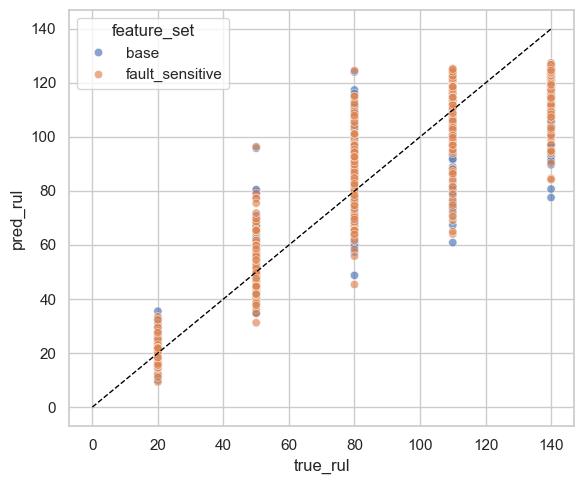

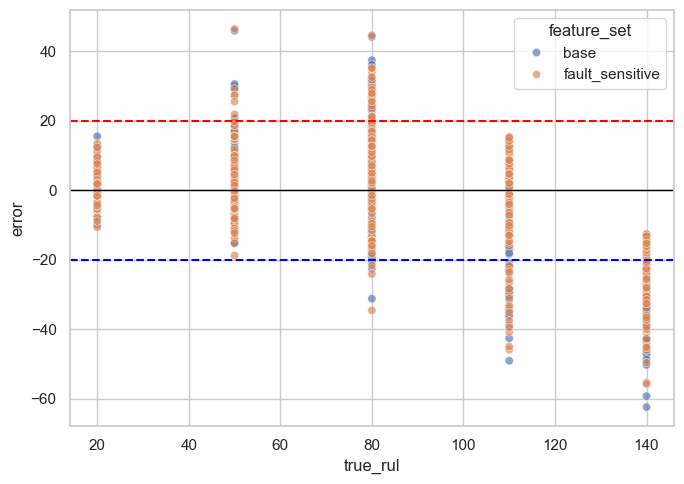

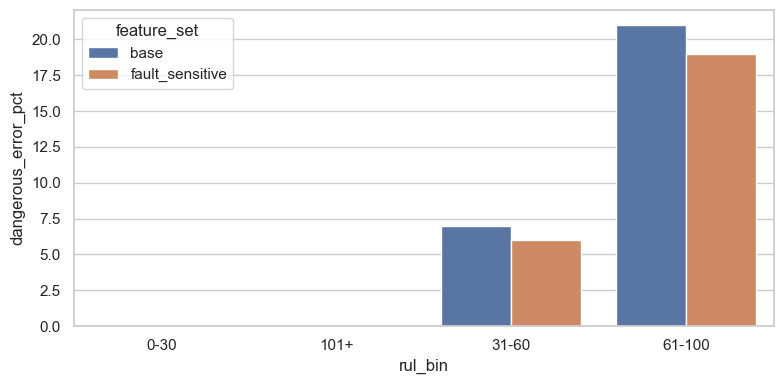

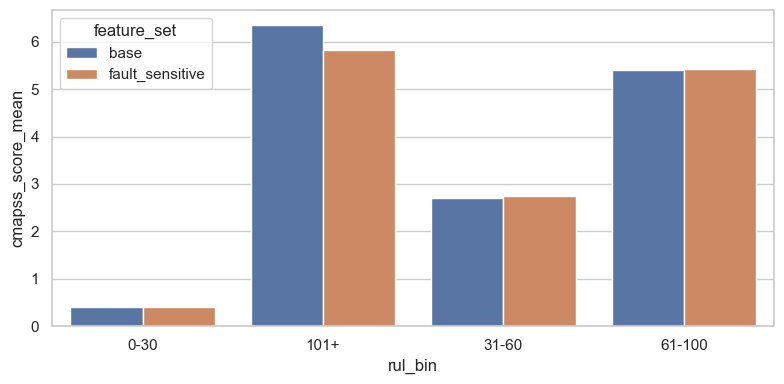

In [6]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=predictions, x='true_rul', y='pred_rul', hue='feature_set', alpha=0.65)
max_axis=max(predictions['true_rul'].max(), predictions['pred_rul'].max())
plt.plot([0,max_axis],[0,max_axis], color='black', linestyle='--', linewidth=1)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'fd003_fault_sensitive_pred_vs_true_comparison.png', dpi=150); plt.show(); plt.close()

plt.figure(figsize=(7,5))
sns.scatterplot(data=predictions, x='true_rul', y='error', hue='feature_set', alpha=0.65)
plt.axhline(0,color='black',linewidth=1); plt.axhline(20,color='red',linestyle='--'); plt.axhline(-20,color='blue',linestyle='--')
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'fd003_fault_sensitive_error_vs_rul.png', dpi=150); plt.show(); plt.close()

plt.figure(figsize=(8,4))
sns.barplot(data=by_bin, x='rul_bin', y='dangerous_error_pct', hue='feature_set')
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'fd003_fault_sensitive_dangerous_by_rul_bin.png', dpi=150); plt.show(); plt.close()

plt.figure(figsize=(8,4))
sns.barplot(data=by_bin, x='rul_bin', y='cmapss_score_mean', hue='feature_set')
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'fd003_fault_sensitive_cmapss_by_rul_bin.png', dpi=150); plt.show(); plt.close()


In [7]:
base = summary.loc[summary['feature_set']=='base'].iloc[0]
fs = summary.loc[summary['feature_set']=='fault_sensitive'].iloc[0]
mid = by_bin.loc[by_bin['rul_bin'].astype(str)=='61-100']
text = f'''FD003 - Fault-sensitive features interpretation

Se comparo el mejor candidato del notebook 21 contra el mismo modelo agregando features sensibles a patrones de degradacion. No se usaron clusters como input ni test oficial.

Base: C-MAPSS {base['mean_cmapss_score']:.3f}, RMSE {base['mean_rmse']:.3f}, dangerous {base['mean_dangerous_error_pct']:.3f}%, conservative {base['mean_conservative_error_pct']:.3f}%.
Fault-sensitive: C-MAPSS {fs['mean_cmapss_score']:.3f}, RMSE {fs['mean_rmse']:.3f}, dangerous {fs['mean_dangerous_error_pct']:.3f}%, conservative {fs['mean_conservative_error_pct']:.3f}%.

El mejor feature_set por criterio principal fue: {best_config['feature_set']}.
En RUL medio 61-100, revisar fd003_fault_sensitive_features_by_rul_bin.csv para ver si la mejora se concentra en ese rango.

Conclusion prudente: las features extra se aceptan solo si mejoran C-MAPSS sin subir de forma relevante dangerous error ni errores conservadores. Si no superan a la base, se conserva el modelo simple.
'''
path = NOTES_DIR / 'fd003_fault_sensitive_features_interpretation.txt'
path.write_text(text, encoding='utf-8')
print(path)
print(text)


C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\notas\FD003\fd003_fault_sensitive_features_interpretation.txt
FD003 - Fault-sensitive features interpretation

Se comparo el mejor candidato del notebook 21 contra el mismo modelo agregando features sensibles a patrones de degradacion. No se usaron clusters como input ni test oficial.

Base: C-MAPSS 424.430, RMSE 16.449, dangerous 5.600%, conservative 13.400%.
Fault-sensitive: C-MAPSS 404.182, RMSE 16.367, dangerous 5.000%, conservative 13.600%.

El mejor feature_set por criterio principal fue: fault_sensitive.
En RUL medio 61-100, revisar fd003_fault_sensitive_features_by_rul_bin.csv para ver si la mejora se concentra en ese rango.

Conclusion prudente: las features extra se aceptan solo si mejoran C-MAPSS sin subir de forma relevante dangerous error ni errores conservadores. Si no superan a la base, se conserva el modelo simple.

